# Figure 3
Vertical wind shear, 850 hPa vorticity, 600 hPa relative humidity (a. factual, b. counterfactual, c. factual-counterfactual) OR (factual-counterfactual a. vws, b. zeta, c. rh)

Import statements

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import xarray as xr
from metpy.units import units
from scipy import stats

## List data

In [5]:
start = 2004
stop = 2023

start1 = 2004
stop1 = 2013

start2 = 2014
stop2 = 2023

# path
path = "/glade/work/smhenry/neuralGCM/Data/ERA5/"

# name
name_list_forcing_cf = [
    path + f"ERA5_forcing_{yr}_JASO_counterfactual.nc" for yr in range(start, stop + 1)
]
name_list_forcing_f = [
    path + f"ERA5_forcing_{yr}_JASO.nc" for yr in range(start, stop + 1)
]

name_list_ensmean_cf = [
    f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_JASO/{yr}_ensmean_JASO_counterfactual_raw.nc"
    for yr in range(start, stop + 1)
]

name_list_ensmean_f = [
    f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_JASO/{yr}_ensmean_JASO_factual_raw.nc"
    for yr in range(start, stop + 1)
]

name_ensmean_d1_cf = f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_decade/{start1}-{stop1}_ensmean_decade_counterfactual_raw.nc"
name_ensmean_d1_f = f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_decade/{start1}-{stop1}_ensmean_decade_factual_raw.nc"

name_ensmean_d2_cf = f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_decade/{start2}-{stop2}_ensmean_decade_counterfactual_raw.nc"
name_ensmean_d2_f = f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_decade/{start2}-{stop2}_ensmean_decade_factual_raw.nc"

name_era5 = "/glade/work/smhenry/neuralGCM/Data/ERA5/ERA5_2004-2023_mean.nc"

# do not need "exclude" functionality because ensmean data already excluded needed members

## Plotting function
Function to plot the data from a given file with given levels for a given variable

In [6]:
def plot_decade_data(
    dat,
    p,
    title,
    ax,
    levels=None,
    cmap=None,
):
    """
    filename: str name of file to plot
    variable: str of name of variable
    level: int level of data
    title: str title of plot
    filename2: str of name of file to take difference with filename
    levels: list or ndarray to define plotting levels, optional
    cmap: str name of colormap
    save: bool
    savename: str name to save to in internal folder "figs"
    """

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([100, 359, -10, 50], crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
    )
    gl.right_labels = False
    gl.top_labels = False
    gl.left_labels = True
    gl.bottom_labels = True

    # plot data
    dat.plot.contourf(
        x="longitude",
        y="latitude",
        levels=levels,
        robust=True,
        ax=ax,
        transform=ccrs.PlateCarree(),
        extend="both",
        cmap=cmap,
        cbar_kwargs={"shrink": 0.8},
    )
    
    if len(p) != 1:
        lon, lat = np.meshgrid(dat.longitude, dat.latitude)
        
        coarsened_pmask = p[::2, ::2]
        coarsened_lat = lat[::2, ::2]
        coarsened_lon = lon[::2, ::2]
        
        ax.scatter(
            coarsened_lon.T[coarsened_pmask],
            coarsened_lat.T[coarsened_pmask],
            color="black",
            s=2,
            transform=ccrs.PlateCarree(),
            marker=".",
        )



    ax.set_title(title, fontsize=12, pad=5)

## Process data

In [7]:
cf_dat = []
f_dat = []
for i in range(len(name_list_ensmean_cf)):
    cf = xr.open_dataset(name_list_ensmean_cf[i])
    f = xr.open_dataset(name_list_ensmean_f[i])

    cf_dat.append(cf)
    f_dat.append(f)

cf_years = xr.concat(cf_dat, dim="year")
f_years = xr.concat(f_dat, "year")

era5 = xr.open_dataset(name_era5)

alpha = 0.05

In [8]:
start = 2004
stop = 2023

start1 = 2004
stop1 = 2013

start2 = 2014
stop2 = 2023

# path
path = "/glade/work/smhenry/neuralGCM/Data/ERA5/"

# name
name_list_forcing_cf = [
    path + f"ERA5_forcing_{yr}_JASO_counterfactual.nc" for yr in range(start, stop + 1)
]
name_list_forcing_f = [
    path + f"ERA5_forcing_{yr}_JASO.nc" for yr in range(start, stop + 1)
]

name_list_ensmean_cf = [
    f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_JASO/{yr}_ensmean_JASO_counterfactual_raw.nc"
    for yr in range(start, stop + 1)
]

name_list_ensmean_f = [
    f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_JASO/{yr}_ensmean_JASO_factual_raw.nc"
    for yr in range(start, stop + 1)
]

name_ensmean_d1_cf = f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_decade/{start1}-{stop1}_ensmean_decade_counterfactual_raw.nc"
name_ensmean_d1_f = f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_decade/{start1}-{stop1}_ensmean_decade_factual_raw.nc"

name_ensmean_d2_cf = f"/glade/work/smhenry/neuralGCM/sims/counterfactual/ensmean_decade/{start2}-{stop2}_ensmean_decade_counterfactual_raw.nc"
name_ensmean_d2_f = f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_decade/{start2}-{stop2}_ensmean_decade_factual_raw.nc"

name_era5 = "/glade/work/smhenry/neuralGCM/Data/ERA5/ERA5_2004-2023_mean.nc"

# do not need "exclude" functionality because ensmean data already excluded needed members

## Plotting function
Function to plot the data from a given file with given levels for a given variable

## Process data

In [9]:
cf_dat = []
f_dat = []
for i in range(len(name_list_ensmean_cf)):
    cf = xr.open_dataset(name_list_ensmean_cf[i])
    f = xr.open_dataset(name_list_ensmean_f[i])

    cf_dat.append(cf)
    f_dat.append(f)

cf_years = xr.concat(cf_dat, dim="year")
f_years = xr.concat(f_dat, "year")

# era5 = xr.open_dataset(name_era5)

alpha = 0.05

VWS

In [10]:
# counterfactual
VWS_cf_years = np.sqrt(
    (
        cf_years.u_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - cf_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
    + (
        cf_years.v_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - cf_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
)
#.rename("VWS [m/s]")
VWS_cf = VWS_cf_years.mean(dim="year")

# factual
VWS_f_years = np.sqrt(
    (
        f_years.u_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - f_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
    + (
        f_years.v_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - f_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
)
#.rename("VWS [m/s]")
VWS_f = VWS_f_years.mean(dim="year")

# ERA5
# VWS_ERA5 = np.sqrt(
#     (
#         era5.u_component_of_wind.sel(level=200, latitude=slice(-10, 50))
#         - era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#     )
#     ** 2
#     + (
#         era5.v_component_of_wind.sel(level=200, latitude=slice(-10, 50))
#         - era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#     )
#     ** 2
# )
# .rename("VWS [m/s]")

# (factual-counterfactual)
dVWS = VWS_f - VWS_cf

# significance
VWS_t_stat, VWS_p_val = stats.ttest_ind(
    VWS_f_years,
    VWS_cf_years,
    axis=0,
    equal_var=False,
)

VWS_p_mask = np.where(dVWS != 0, VWS_p_val < alpha, False)

850hPa vorticity

In [11]:
# counterfactual
Zeta850_cf_years = (
    mpcalc.vorticity(
        cf_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        cf_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Vort. [s-1]")
    .metpy.dequantify()
)
Zeta850_cf = Zeta850_cf_years.mean(dim="year")
# Zeta850_cf.attrs["units"] = "s-1"

# factual
Zeta850_f_years = (
    mpcalc.vorticity(
        f_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        f_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Vort. [s-1]")
    .metpy.dequantify()
)
Zeta850_f = Zeta850_f_years.mean(dim="year")
# Zeta850_f.attrs["units"] = "s-1"

# ERA5
# Zeta850_ERA5 = (
#     mpcalc.vorticity(
#         era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#         * units("m/s"),
#         era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#         * units("m/s"),
#     )
#     # .rename("Vort. [s-1]")
#     .metpy.dequantify()
# ).drop_attrs()

# (factual-counterfactual)
dZeta850 = Zeta850_f - Zeta850_cf
# dZeta850.attrs["units"] = "s-1"

# significance
Zeta850_t_stat, Zeta850_p_val = stats.ttest_ind(
    Zeta850_f_years,
    Zeta850_cf_years,
    axis=0,
    equal_var=False,
)

Zeta850_p_mask = np.where(dZeta850 != 0, Zeta850_p_val < alpha, False)

850hPa divergence

In [12]:
# counterfactual
div_cf_years = (
    mpcalc.divergence(
        cf_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        cf_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Div. [s-1]")
    .metpy.dequantify()
)
div_cf = div_cf_years.mean(dim="year")
# div_cf.attrs["units"] = "s-1"

# factual
div_f_years = (
    mpcalc.divergence(
        f_years.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        f_years.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Div. [s-1]")
    .metpy.dequantify()
)
div_f = div_f_years.mean(dim="year")
# div_f.attrs["units"] = "s-1"

# ERA5
# div_ERA5 = (
#     mpcalc.divergence(
#         era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#         * units("m/s"),
#         era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
#         * units("m/s"),
#     )
#     # .rename("Div. [s-1]")
#     .metpy.dequantify()
# ).drop_attrs()


# (factual-counterfactual)
d_div = div_f - div_cf
# d_div.attrs["units"] = "s-1"

# significance
div_t_stat, div_p_val = stats.ttest_ind(
    div_f_years,
    div_cf_years,
    axis=0,
    equal_var=False,
)

div_p_mask = np.where(d_div != 0, div_p_val < alpha, False)

600hPa relative humidity

In [13]:
RH600_cf_years = (
    mpcalc.relative_humidity_from_specific_humidity(
        600 * units.hPa,
        cf_years.temperature.sel(level=600, latitude=slice(-10, 50)) * units.K,
        cf_years.specific_humidity.sel(level=600, latitude=slice(-10, 50)),
    )
    # .rename("RH")
    .metpy.dequantify()
    * 100
)
# RH600_cf_years.attrs["units"] = "%"
RH600_cf = RH600_cf_years.mean(dim="year")

RH600_f_years = (
    mpcalc.relative_humidity_from_specific_humidity(
        600 * units.hPa,
        f_years.temperature.sel(level=600, latitude=slice(-10, 50)) * units.K,
        f_years.specific_humidity.sel(level=600, latitude=slice(-10, 50)),
    )
    # .rename("RH")
    .metpy.dequantify()
    * 100
)
RH600_f = RH600_f_years.mean(dim="year")
# RH600_f.attrs["units"] = "%"

# ERA5
# RH600_ERA5 = (
#     mpcalc.relative_humidity_from_specific_humidity(
#         600 * units.hPa,
#         era5.temperature.sel(level=600, latitude=slice(-10, 50)) * units.K,
#         era5.specific_humidity.sel(level=600, latitude=slice(-10, 50)),
#     )
#     # .rename("RH")
#     .metpy.dequantify()
#     * 100
# )
# RH600_ERA5.attrs["units"] = "%"

# (factual-counterfactual)
dRH600 = RH600_f - RH600_cf
# dRH600.attrs["units"] = "%"

# significance
RH600_t_stat, RH600_p_val = stats.ttest_ind(
    RH600_f_years,
    RH600_cf_years,
    axis=0,
    equal_var=False,
)

RH600_p_mask = np.where(dRH600 != 0, RH600_p_val < alpha, False)

VWS

In [14]:
# ERA5
VWS_ERA5 = np.sqrt(
    (
        era5.u_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
    + (
        era5.v_component_of_wind.sel(level=200, latitude=slice(-10, 50))
        - era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
    )
    ** 2
)

850hPa vorticity

In [15]:
# ERA5
Zeta850_ERA5 = (
    mpcalc.vorticity(
        era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Vort. [s-1]")
    .metpy.dequantify()
).drop_attrs()

850hPa divergence

In [16]:
# ERA5
div_ERA5 = (
    mpcalc.divergence(
        era5.u_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
        era5.v_component_of_wind.sel(level=850, latitude=slice(-10, 50))
        * units("m/s"),
    )
    # .rename("Div. [s-1]")
    .metpy.dequantify()
).drop_attrs()

600hPa relative humidity

In [17]:
# ERA5
RH600_ERA5 = (
    mpcalc.relative_humidity_from_specific_humidity(
        600 * units.hPa,
        era5.temperature.sel(level=600, latitude=slice(-10, 50)) * units.K,
        era5.specific_humidity.sel(level=600, latitude=slice(-10, 50)),
    )
    # .rename("RH")
    .metpy.dequantify()
    * 100
)

## Plot

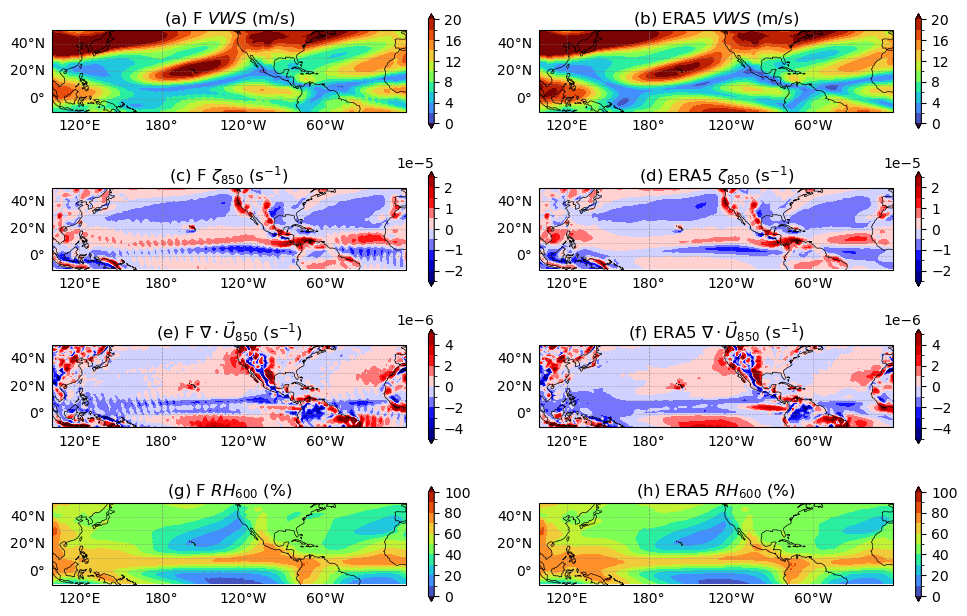

In [18]:
fig, axs = plt.subplots(
    ncols=2,
    nrows=4,
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
axs = axs.flatten()

lev_VWS = np.arange(0, 20 + 2, 2)
lev_zeta = np.arange(-2.5e-5, 2.5e-5 + 2.5e-5 / 5, 2.5e-5 / 5)
lev_div = np.arange(-5e-6, 5e-6+5e-6/5, 5e-6/5)
lev_rh = np.arange(0, 100 + 100 / 10, 100 / 10)

dat_list = [VWS_f, VWS_ERA5, Zeta850_f, Zeta850_ERA5, div_f, div_ERA5, RH600_f, RH600_ERA5]
pmask_list = [[np.nan], [np.nan], [np.nan], [np.nan], [np.nan], [np.nan], [np.nan], [np.nan]]
title_list = [
    r"(a) F $VWS$ (m/s)",
    r"(b) ERA5 $VWS$ (m/s)",
    r"(c) F $\zeta_{850}$ (s$^{-1}$)",
    r"(d) ERA5 $\zeta_{850}$ (s$^{-1}$)",
    r"(e) F $\nabla\cdot\vec{U}_{850}$ (s$^{-1}$)",
    r"(f) ERA5 $\nabla\cdot\vec{U}_{850}$ (s$^{-1}$)",
    r"(g) F $RH_{600}$ (%)",
    r"(h) ERA5 $RH_{600}$ (%)",
]
level_list = [lev_VWS, lev_VWS, lev_zeta, lev_zeta, lev_div, lev_div, lev_rh, lev_rh]
cmap_list = ["turbo", "turbo", "seismic", "seismic", "seismic", "seismic", "turbo", "turbo"]

for i in range(len(axs)):
    plot_decade_data(
        dat_list[i],
        pmask_list[i],
        title_list[i],
        axs[i],
        levels=level_list[i],
        cmap=cmap_list[i],
    )

plt.subplots_adjust(wspace=0.1, hspace=.1)
plt.savefig("./figs/figureSI_ERA5_vars.png", dpi=600, bbox_inches="tight")
plt.show()